In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pycontrails import Fleet

In [2]:
df = pd.read_parquet("../data/filed_aCCF_comparison_EAGWP100_[150, 350].parquet").rename(columns={
    "Matthes et al. (unpublished)": "Matthes et al. (2023)"
})
# df = df.transpose()[["CO2", "CoCiP", "CO2_with_aCCF", "NOx", "O3", "CH4", "H2O"]].transpose()
df

,van Manen & Grewe (2019),Yin et al. (2023) / Dietmüller et al. (2023),Matthes et al. (2023)
CO2,94.499654,94.499654,94.499654
CO2_with_aCCF,34.001816,34.001816,34.001816
CoCiP,61.888543,61.888543,61.888543
CiC,10.966928,21.546027,7.182009
NOx,229.871318,229.305782,64.755803
O3,425.260450,424.937498,76.102443
CH4,-195.389133,-195.631716,-11.346640
H2O,8.279387,8.292656,5.307300


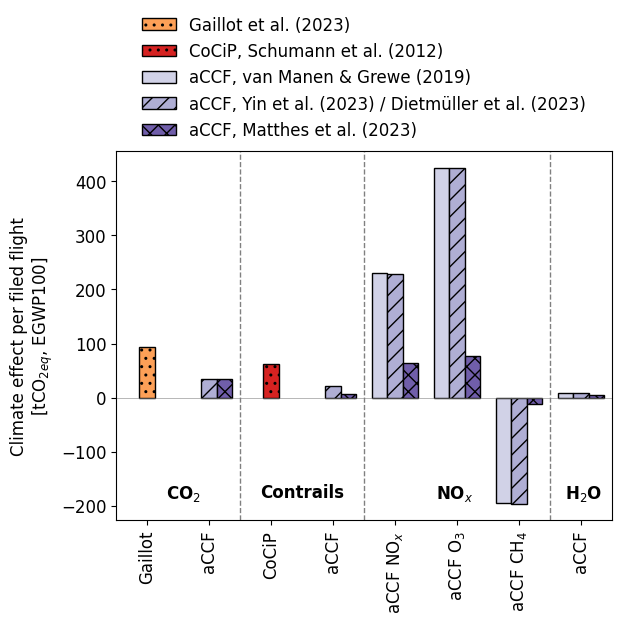

In [3]:
x = np.arange(len(df))
width = 0.25
cols = df.columns  # your 3 bar categories

hide = {
    0: [0, 2],  # row 0: hide 1st and last bar
    1: [0],
    2: [0, 2],
    3: [0],
}

styles = {
    0: dict(color=sns.color_palette("Purples")[1], hatch=''),
    1: dict(color=sns.color_palette("Purples")[2], hatch='//'),
    2: dict(color=sns.color_palette("Purples")[4], hatch='xx'),
}
# Override for specific (row, col) combinations
style_overrides = {
    (0, 1): dict(color=sns.color_palette("Oranges")[2], hatch='..'),
    (2, 1): dict(color=sns.color_palette("Reds")[4], hatch='..'),
}

fig, ax = plt.subplots()
for i, (idx, row) in enumerate(df.iterrows()):
    for j, (col, val) in enumerate(row.items()):
        offset = (j - 1) * width
        w = 0 if j in hide.get(i, []) else width
        ecolor = "None" if j in hide.get(i, []) else "black"
        style = style_overrides.get((i, j), styles[j])
        ax.bar(i + offset, val, w, **style, edgecolor=ecolor)

ax.axhline(0, color='gray', linewidth=0.4)

ax.axvline(x=1.5, color='gray', linestyle='--', linewidth=1)
ax.axvline(x=3.5, color='gray', linestyle='--', linewidth=1)
ax.axvline(x=6.5, color='gray', linestyle='--', linewidth=1)

ax.text(
    0.17, 0.1, "CO$_2$",
    transform=ax.transAxes,
    fontsize=12, fontweight="bold",
    va="top", ha="right"
)
ax.text(
    0.46, 0.1, "Contrails",
    transform=ax.transAxes,
    fontsize=12, fontweight="bold",
    va="top", ha="right"
)
ax.text(
    0.72, 0.1, "NO$_x$",
    transform=ax.transAxes,
    fontsize=12, fontweight="bold",
    va="top", ha="right"
)
ax.text(
    0.98, 0.1, "H$_2$O",
    transform=ax.transAxes,
    fontsize=12, fontweight="bold",
    va="top", ha="right"
)

### independent legend
from matplotlib.patches import Patch

legend_items = [
    Patch(facecolor=sns.color_palette("Oranges")[2], hatch='..', label='Gaillot et al. (2023)', edgecolor='black'),
    #, edgecolor='black'),
    Patch(facecolor=sns.color_palette("Reds")[4], hatch='..', label='CoCiP, Schumann et al. (2012)',
          edgecolor='black'),
    Patch(facecolor=sns.color_palette("Purples")[1], hatch='', label=f"aCCF, {df.columns[0]}", edgecolor='black'),
    #, edgecolor='black'),
    Patch(facecolor=sns.color_palette("Purples")[2], hatch='//', label=f"aCCF, {df.columns[1]}", edgecolor='black'),
    Patch(facecolor=sns.color_palette("Purples")[4], hatch='xx', label=f"aCCF, {df.columns[2]}", edgecolor='black'),
]

ax.legend(handles=legend_items, loc='lower center', bbox_to_anchor=(0.5, 0.99), ncol=1,
          fontsize=12, edgecolor='none')

### Ticks and axis labels
ax.set_xticks(np.arange(len(df)))
ax.set_xlim([0 - 2 * width, len(df) - 1 + 2 * width])
xlabels = ['Gaillot', 'aCCF', 'CoCiP', 'aCCF', 'aCCF NO$_x$', 'aCCF O$_3$', 'aCCF CH$_4$', 'aCCF']
ax.set_xticklabels(xlabels, rotation=90)  #, ha='right')

ax.set_ylabel("Climate effect per filed flight\n[tCO$_{2eq}$, EGWP100]", fontsize=12)

ax.tick_params(labelsize=12)

plt.savefig("./figures/figD1.png", dpi=300, bbox_inches='tight')